# Vorbereiten der Daten zur Modellbildung

Dieses Notebook lädt die Daten aus dem ucimlrepo. Anschließend werden die Daten soweit präpariert, dass sie dem Modell übergeben werden können.

---

## 1. Setup & Daten laden



In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from ucimlrepo import fetch_ucirepo 
import textwrap
# fetch dataset 
mushroom = fetch_ucirepo(id=73) 

## 2. Daten einlesen & erste Anpassungen


In [2]:
# Print the summary of the data set
summary = mushroom.metadata.additional_info.summary
print(textwrap.fill(summary, width=80))
print('-' * 30)

# original data frame
df = mushroom.data.original.copy()

# The intern mushroom.variables data frame has a lot of information
# But I want to expand it
side_info = mushroom.variables.copy()

# It should contain the number of unique values (nr of categories)
nr_of_unique_list = []
for name in side_info['name']:
    nr_of_unique_list.append( df[name].nunique() )
side_info['nr_of_uniques'] = nr_of_unique_list

# Also the number of missing values would be nice
missing_data = pd.DataFrame(df.isnull().sum(), columns=['nr_missing'])
missing_data['name'] = missing_data.index

side_info = side_info.merge(missing_data)
side_info = side_info.drop(['units', 'demographic'], axis=1)

# In the case of one hot encoding all non binary categories,
# how many features would I get
nr_feat = 0
for i in range(1, side_info.shape[0]):
    if side_info.iloc[i].type == 'Binary':
        nr_feat += 1
    else:
        nr_feat += side_info.iloc[1].nr_of_uniques

# Given that the whole of the categories define a single mushroom,
# how many different combinations of categories do we have
nr_comb = 1
for i in range(1, side_info.shape[0]):
    nr_comb *= side_info.iloc[1].nr_of_uniques

# print it
print(f'With One-Hot-Encoding the non-binary categories there would be {nr_feat} features.')
print(f'There are {nr_comb} possible combinations.')


# Display the side info data frame
display(side_info)

This data set includes descriptions of hypothetical samples corresponding to 23
species of gilled mushrooms in the Agaricus and Lepiota Family (pp. 500-525).
Each species is identified as definitely edible, definitely poisonous, or of
unknown edibility and not recommended.  This latter class was combined with the
poisonous one.  The Guide clearly states that there is no simple rule for
determining the edibility of a mushroom; no rule like ``leaflets three, let it
be'' for Poisonous Oak and Ivy.
------------------------------
With One-Hot-Encoding the non-binary categories there would be 122 features.
There are 131621703842267136 possible combinations.


,name,role,type,description,missing_values,nr_of_uniques,nr_missing
0,poisonous,Target,Categorical,None,no,2,0
1,cap-shape,Feature,Categorical,"bell=b,conical=c,convex=x,flat=f, knobbed=k,su...",no,6,0
2,cap-surface,Feature,Categorical,"fibrous=f,grooves=g,scaly=y,smooth=s",no,4,0
3,cap-color,Feature,Binary,"brown=n,buff=b,cinnamon=c,gray=g,green=r, pink...",no,10,0
4,bruises,Feature,Categorical,"bruises=t,no=f",no,2,0
5,odor,Feature,Categorical,"almond=a,anise=l,creosote=c,fishy=y,foul=f, mu...",no,9,0
6,gill-attachment,Feature,Categorical,"attached=a,descending=d,free=f,notched=n",no,2,0
7,gill-spacing,Feature,Categorical,"close=c,crowded=w,distant=d",no,2,0
8,gill-size,Feature,Categorical,"broad=b,narrow=n",no,2,0
9,gill-color,Feature,Categorical,"black=k,brown=n,buff=b,chocolate=h,gray=g, gre...",no,12,0


**Auswirkung:**
Das Feature `stalk-root` hat 2480 fehlende Werte. Dafür werde ich eine neue Kategorie erstellen unter die alle fehlenden Werte fallen.
Das Feature `veil-type`besteht aus nur einer Kategorie. Daher werde ich dieses Feature entfernen.

In [3]:
df = mushroom.data.original.copy()

# drop the feature veil-type
df = df.drop('veil-type', axis=1)

# Adapt the info data frame
drop_id = side_info[ side_info['name'] == 'veil-type'].index
side_info = side_info.drop([drop_id[0]])

# Call the missing data in stalk-root u for unknown
df.loc[ df['stalk-root'].isna(), 'stalk-root'] = 'u'

# Add this info to the info data frame
sr_id = side_info[ side_info['name'] == 'stalk-root'].index
side_info.loc[sr_id, 'description'] = side_info.loc[sr_id, 'description'] + ',unknown=u'

# We no longer need missing values as info
side_info = side_info.drop(['missing_values', 'nr_missing'], axis=1)
display(side_info)

# save side info
side_info.to_csv('../data/processed/side_info.csv')


,name,role,type,description,nr_of_uniques
0,poisonous,Target,Categorical,None,2
1,cap-shape,Feature,Categorical,"bell=b,conical=c,convex=x,flat=f, knobbed=k,su...",6
2,cap-surface,Feature,Categorical,"fibrous=f,grooves=g,scaly=y,smooth=s",4
3,cap-color,Feature,Binary,"brown=n,buff=b,cinnamon=c,gray=g,green=r, pink...",10
4,bruises,Feature,Categorical,"bruises=t,no=f",2
5,odor,Feature,Categorical,"almond=a,anise=l,creosote=c,fishy=y,foul=f, mu...",9
6,gill-attachment,Feature,Categorical,"attached=a,descending=d,free=f,notched=n",2
7,gill-spacing,Feature,Categorical,"close=c,crowded=w,distant=d",2
8,gill-size,Feature,Categorical,"broad=b,narrow=n",2
9,gill-color,Feature,Categorical,"black=k,brown=n,buff=b,chocolate=h,gray=g, gre...",12


**Verteilung der Daten visualisieren:**

Wenn es die Umstände verlangen, verwende ich eine logarithmische Skalierung. Also immer auf die Skalierung achten.

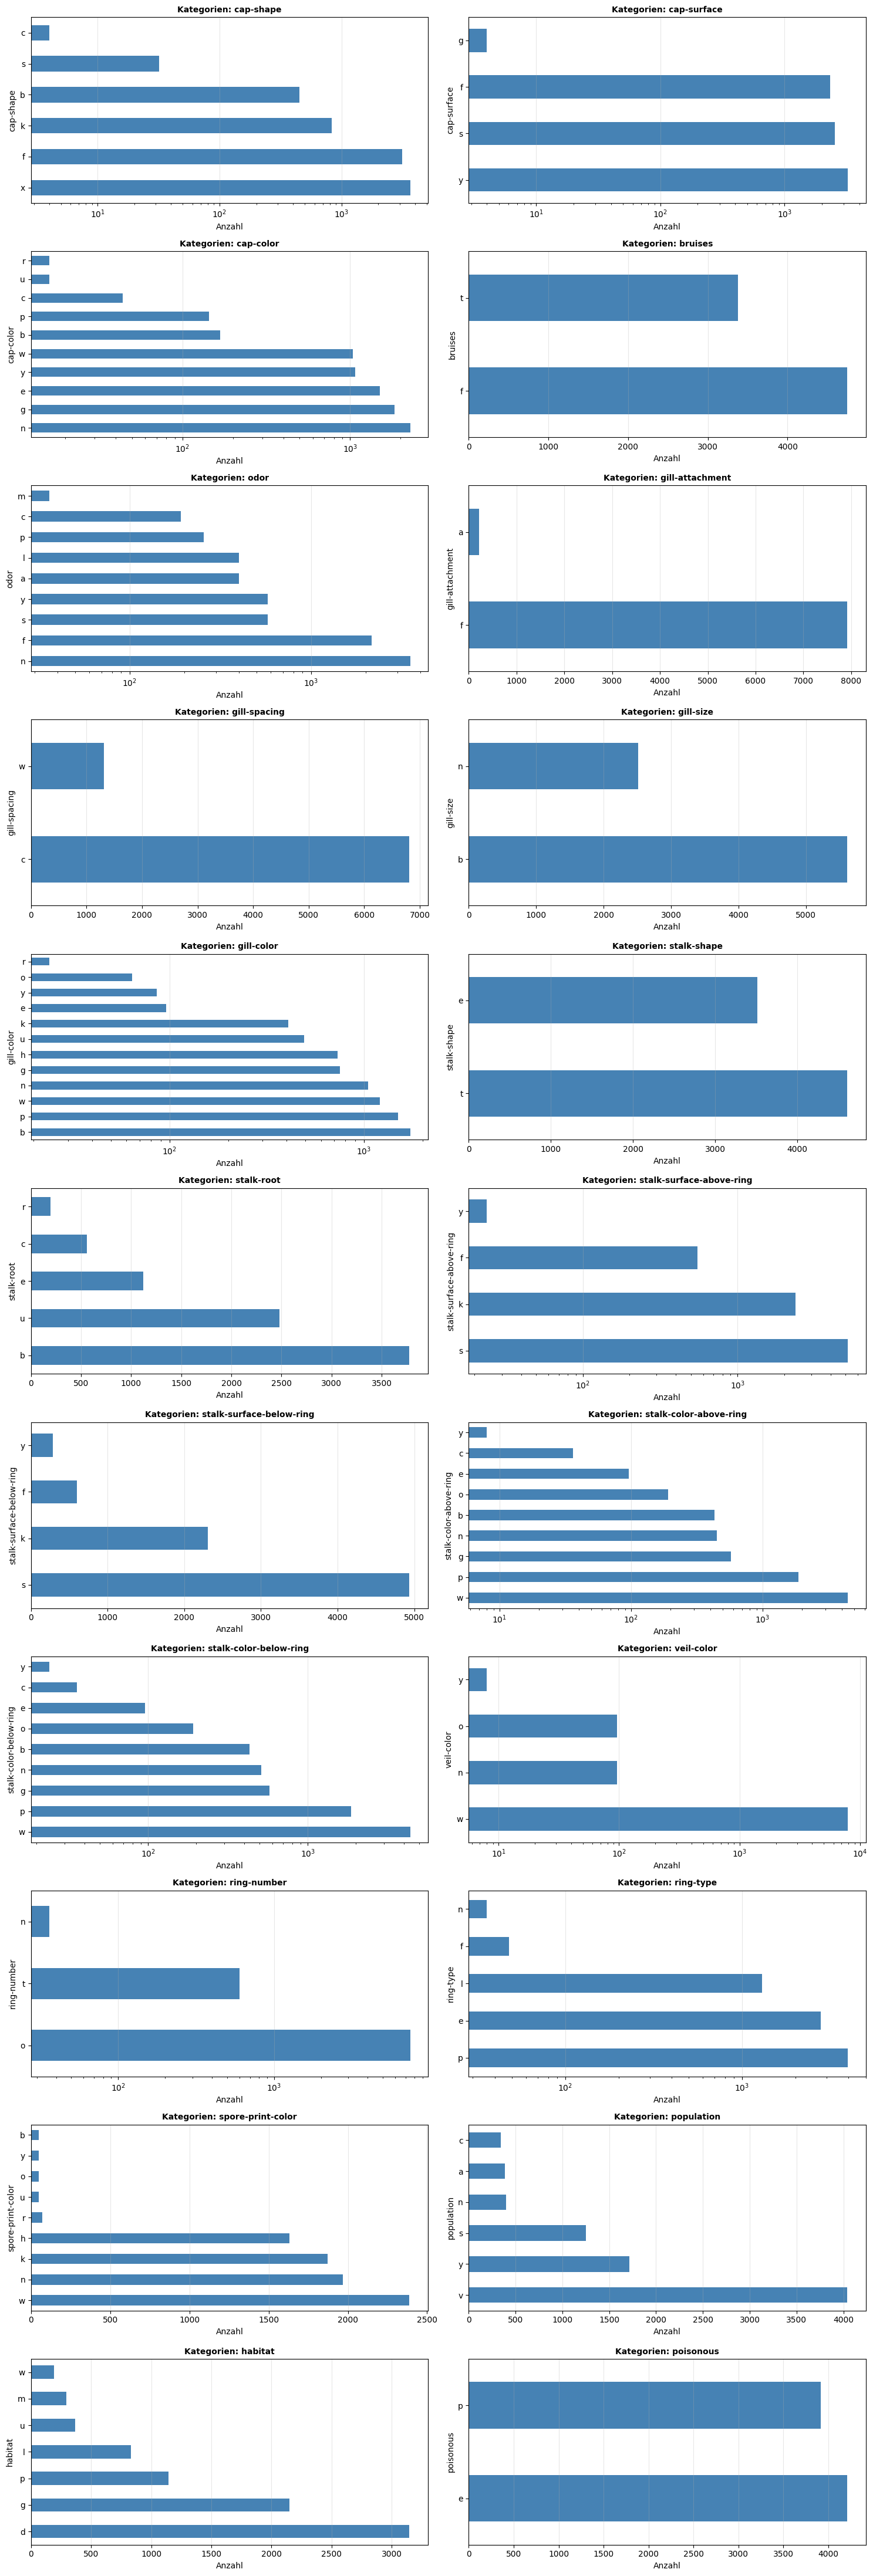

In [4]:
# Kategorien visualisieren
n_cols = 2
n_rows = (len(df.columns) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
axes = axes.flatten()

for idx, col in enumerate(df.columns):
    ax = axes[idx]
    value_counts = df[col].value_counts()
    value_counts.plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title(f'Kategorien: {col}', fontsize=10, fontweight='bold')
    ax.set_xlabel('Anzahl')
    # adapt scale if necessary
    if value_counts.max() / value_counts.min() > 50:
        ax.set_xscale('log')
    ax.grid(alpha=0.3, axis='x')

# Leere Subplots ausblenden
for idx in range(len(df.columns), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()


Wie wir sehen gibt es Kategorien in den Features, die deutlich weniger vertreten sind. Das Target, poisonous, ist hier aber recht ausgeglichen.

## 3. Train-Test-Split

In [5]:
from sklearn.model_selection import train_test_split
features = df.drop('poisonous', axis=1)
target = df['poisonous']
features_train, features_test, target_train, target_test = train_test_split(features,
                                                                            target,
                                                                            test_size=0.2,
                                                                            random_state=42)

# save data frames
df.to_csv('../data/processed/all_data.csv')
features_train.to_csv('../data/processed/features_train.csv')
features_test.to_csv('../data/processed/features_test.csv')
target_train.to_csv('../data/processed/target_train.csv')
target_test.to_csv('../data/processed/target_test.csv')